In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score, recall_score, precision_score, cohen_kappa_score

In [2]:
# Get index-wise performances
window_len = 256
fold_f1_i = []
fold_prec_i = []
fold_rec_i = []

fold_auc_i = []
for fold in os.scandir('/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae/tbi_validation/sleep/'):
    fold_targets = []
    fold_preds = []
    for sub in os.scandir(fold):
        targets = np.load(os.path.join(sub.path, 'targets.npy'))
        soft_preds_aligned = np.load(os.path.join(sub.path, 'y_hat_aligned.npy'))
        for i in range(len(soft_preds_aligned)):
            fold_targets.append(targets[i : window_len + i])
            fold_preds.append(soft_preds_aligned[i, i : window_len + i])

    fold_targets = np.stack(fold_targets)
    fold_scores = np.stack(fold_preds)
    fold_scores = np.exp(fold_scores) / np.exp(fold_scores).sum(-1, keepdims=True)
    fold_preds = np.stack(fold_preds).argmax(axis=-1)
    
    f1_i = []
    prec_i = []
    rec_i = []
    auc_i = []
    for i in range(window_len):
        targets_i = fold_targets[:, i]
        filt = targets_i != -9
        preds_i = fold_preds[filt, i]
        scores_i = fold_scores[filt, i, :]
        targets_i = targets_i[filt]
        f1_i.append(f1_score(targets_i, preds_i, average=None, labels = [0,1,2,3]))
        prec_i.append(precision_score(targets_i, preds_i, average=None, labels = [0,1,2,3]))
        rec_i.append(recall_score(targets_i, preds_i, average=None, labels = [0,1,2,3]))
        auc_i.append(roc_auc_score(targets_i, scores_i, average=None, multi_class='ovr', labels = [0,1,2,3]))
    fold_f1_i.append(f1_i)
    fold_prec_i.append(prec_i)
    fold_rec_i.append(rec_i)
    fold_auc_i.append(auc_i)
    

fold_f1_i = np.stack(fold_f1_i)
fold_prec_i = np.stack(fold_prec_i)
fold_rec_i = np.stack(fold_rec_i)
fold_auc_i = np.stack(fold_auc_i)


In [ ]:
# mean_auc = fold_auc_i.mean(-1).mean(0)
# norm_auc_weights = (mean_auc-mean_auc.min())/(mean_auc.max()-mean_auc.min())
# triangle_weights = np.concatenate([
#     np.linspace(0,1,norm_auc_weights.argmax()),
#     np.linspace(0,1,len(norm_auc_weights)-norm_auc_weights.argmax(),endpoint=False)[::-1],
# ])
# save_path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/'
# plt.plot(norm_auc_weights)
# plt.plot(triangle_weights)
# np.save(save_path + 'norm_auc_weights.npy', norm_auc_weights)
# np.save(save_path + 'triangle_weights.npy', triangle_weights)
norm_auc_weights = np.load('/oak/stanford/groups/mignot/projects/actigraphy_fm/results/norm_auc_weights.npy')
triangle_weights = np.load('/oak/stanford/groups/mignot/projects/actigraphy_fm/results/triangle_weights.npy')

plt.figure(dpi=600,figsize=(5,3))
plt.plot(norm_auc_weights, label='Normalized AUC weights')
plt.plot(triangle_weights, label='Triangle weights')
plt.ylabel('Weight')
plt.xlabel('Sequence Position')
plt.legend(loc='lower center')

In [12]:
import os
import glob
import json
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as cl
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
import pandas as pd
from collections import defaultdict
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    f1_score,
    cohen_kappa_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
)

def safe_cw_auc(targets, scores, mode = 'ovo', count_lim = 2):
    unique_targets, counts = np.unique(targets, return_counts=True)
    unique_targets = unique_targets[counts > count_lim]
    cw_auc = np.full(scores.shape[-1], np.nan)
    if len(unique_targets) == 1:
        return cw_auc
    for k in unique_targets:
        if mode == 'ovo':
            cw_auc[k] = 0
            for l in unique_targets:
                if l == k: continue
                tmp_mask = np.logical_or(targets == k, targets == l)
                tmp_targets = targets[tmp_mask]
                tmp_scores = scores[tmp_mask, k]
                cw_auc_kvl = roc_auc_score(tmp_targets == k,tmp_scores)
                cw_auc[k] += cw_auc_kvl/(len(unique_targets -1))
        elif mode == 'ovr':
            cw_auc[k] = roc_auc_score(targets == k, scores[:, k])
        else:
            raise "Mode must be ovo or ovr"
    return cw_auc

def safe_cw_pr_re_f1(targets, preds, num_classes, count_lim = 2):
    unique_targets, counts = np.unique(targets, return_counts=True)

    # Target count filter
    count_filt = np.full(num_classes, np.nan)
    count_filt[unique_targets[counts > count_lim]] = 1 

    # Calculate scores (results will only include present targets)
    cw_prec = precision_score(targets, preds, average=None, zero_division=np.nan)
    cw_rec = recall_score(targets, preds, average=None, zero_division=np.nan)
    cw_f1 = f1_score(targets, preds, average=None, zero_division=np.nan)

    # Initialize NaN arrays to fill to make sure all possible targets are representet
    cw_prec_array = np.full(num_classes, np.nan)
    cw_rec_array = np.full(num_classes, np.nan)
    cw_f1_array = np.full(num_classes, np.nan)

    # Fill in NaN arrays
    for i, k in enumerate(unique_targets):
        cw_prec_array[k] = cw_prec[i] * count_filt[i]
        cw_rec_array[k] = cw_rec[i] * count_filt[i]
        cw_f1_array[k] = cw_f1[i] * count_filt[i]

    return cw_prec_array, cw_rec_array, cw_f1_array

def calc_sleep_summary_metrics(stages, label_map):
    metrics = {}
    # Calculate TST
    sleep = stages != label_map['wake']
    tst = (sleep).sum()
    metrics['tst'] = float(tst)
    
    try:
        # Calculate SOL (first consecutive 3-epoch sleep window)
        # [[sleep, False, False],
        # [False, sleep, False],
        # [False, False, sleep]]
        sleep_shifted = np.stack([
            np.append(sleep, [False, False]),
            np.insert(np.append(sleep, [False]), 0, [False]),
            np.insert(sleep, 0, [False, False]),
        ])
        sol = np.argwhere(sleep_shifted.all(axis=0)).min()
        metrics['sol'] = float(sol)

        # Calculate WASO, how to handle missing?
        # Trim back from the last index if it is wake
        # Find last index of sleep 
        last_sleep = np.argwhere(stages != label_map['wake']).max() + 1
        waso = (stages[sol: last_sleep] == label_map['wake']).sum()
        metrics['waso'] = float(waso)
    except:
        metrics['sol'] = np.nan
        metrics['waso'] = np.nan
    # Calculate SE
    # se = (stages[sol: last_sleep] != label_map['wake']).sum() / (last_sleep - sol)
    se = (stages != label_map['wake']).sum() / len(stages)
    metrics['se'] = float(se)

    # Calculate REM
    rem = (stages == ss_label_map['rem']).sum()
    metrics['rem'] = float(rem)
    
    # Calculate Deep
    deep = (stages == ss_label_map['deep']).sum()
    metrics['deep'] = float(deep)

    # Calculate Light
    light = (stages == ss_label_map['light']).sum()
    metrics['light'] = float(light)

    # Calculate NREM
    nrem = light + deep
    metrics['nrem'] = float(nrem)

    return metrics

ss_labels_name = 'light_deep_rem'
ss_label_map = {
    'deep': 0,
    'light': 1,
    'rem': 2,
    'wake': 3,
    'missing': -9,
}
# ss_label_map_inv = {val: key for key, val in ss_label_map.items()}
ss_label_map_inv = {val: key for key, val in ss_label_map.items() if val != -9}
ss_label_order = ['wake', 'light', 'deep', 'rem']
ss_label_name = ['Wake', 'Light', 'Deep', 'REM']

ss_colormap = {
    'wake': 'tab:red',
    'Wake': 'tab:red',
    'light': 'tab:orange',
    'Light': 'tab:orange',
    'deep': 'tab:blue',
    'Deep': 'tab:blue',
    'rem': 'tab:green',
    'REM': 'tab:green',
}
ss_case_map = {
    'wake':'Wake',
    'light': 'Light',
    'deep': 'Deep',
    'rem': 'REM',
}


In [ ]:
# Test weighting performance
cw_precs = defaultdict(list)
cw_recalls = defaultdict(list)
cw_f1s = defaultdict(list)

cw_aucs = defaultdict(list)
roc_curves = defaultdict(list)
soft_preds_all = []
targets_all = []

macro_results = defaultdict(list)
summary_diffs = defaultdict(list)
summary_means = defaultdict(list)
exp_i = []
fold_i = []
subject_i = []
exp1_path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_tbi_cv/no_weights'
exp2_path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_tbi_cv/auc_weights'
exp3_path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_tbi_cv/triangle_weights'
experiments = [('Unweighted', exp1_path), ('Normalized AUC', exp2_path), ('Triangle', exp3_path)]
for exp_name, experiment_dir in experiments:
    print(exp_name)
    for fold_dir in os.scandir(experiment_dir):
        if exp_name == 'Normalized AUC' or exp_name == 'Triangle':
            fold_dir = os.path.join(fold_dir, 'tbi')
        for sub_dir in os.scandir(fold_dir):
            subject_i.append(os.path.basename(sub_dir))
            fold_i.append(os.path.basename(fold_dir))
            exp_i.append(exp_name)
            missing_idx = ss_label_map['missing']

            scores = np.load(os.path.join(sub_dir.path + '/soft_preds.npy'))
            targets = np.load(os.path.join(sub_dir.path + '/targets.npy'))

            scores = scores[targets != missing_idx]
            targets = targets[targets != missing_idx]
            
            soft_preds_all.append(scores)
            targets_all.append(targets)
            
            # Get hard predictions
            preds = scores.argmax(axis=-1)

            unique_targets, counts = np.unique(targets, return_counts=True)
            unique_preds, pred_counts = np.unique(preds, return_counts=True)

            ## Subject-wise class-wise scores
            # Precision, Recall, and F1
            cw_pr, cw_re, cw_f1 = safe_cw_pr_re_f1(targets, preds, num_classes=scores.shape[-1], count_lim=3)
            
            # Manually compute binary AUC for each label present (NaN for non-valid)
            cw_auc = safe_cw_auc(targets, scores, mode='ovr', count_lim=3)

            for k in range(scores.shape[-1]):
                cw_aucs[ss_label_map_inv[k]].append(float(cw_auc[k]))
                cw_precs[ss_label_map_inv[k]].append(float(cw_pr[k]))
                cw_recalls[ss_label_map_inv[k]].append(float(cw_re[k]))
                cw_f1s[ss_label_map_inv[k]].append(float(cw_f1[k]))

            # Class-wise ROC curves
            for k in unique_targets:
                roc = roc_curve(targets, scores[:,k], pos_label=k)
                roc_curves[ss_label_map_inv[k]].append(roc)
            
            ## Subject-wise macro averages
            mac_prec = precision_score(targets, preds, average='macro', zero_division=np.nan)
            mac_rec = recall_score(targets, preds, average='macro', zero_division=np.nan)
            mac_f1 = f1_score(targets, preds, average='macro', zero_division=np.nan)
            kappa = cohen_kappa_score(targets, preds)
            macro_results['Precision'].append(mac_prec)
            macro_results['Recall'].append(mac_rec)
            macro_results['F1'].append(mac_f1)
            macro_results['Kappa'].append(kappa)
            macro_results['AUC'].append(np.nanmean(cw_auc))

            pred_metrics = calc_sleep_summary_metrics(preds, ss_label_map)
            target_metrics = calc_sleep_summary_metrics(targets, ss_label_map)
            summary_diff = {
                f'{key}': pred_metrics[key] - target_metrics[key]
                for key
                in pred_metrics.keys()
            }
            summary_mean = {
                f'{key}': (pred_metrics[key] + target_metrics[key])/2 
                for key 
                in pred_metrics.keys()
            }
            for key in summary_diff.keys():
                summary_diffs[key].append(summary_diff[key])
                summary_means[key].append(summary_mean[key])
            

macro_results = pd.DataFrame(data=macro_results)
cw_aucs = pd.DataFrame(data=cw_aucs)
cw_precs = pd.DataFrame(data=cw_precs)
cw_recalls = pd.DataFrame(data=cw_recalls)
cw_f1s = pd.DataFrame(data=cw_f1s)
summary_means = pd.DataFrame(data=summary_means)
summary_diffs = pd.DataFrame(data=summary_diffs)
for col in summary_means.columns:
    if col == 'se':
        factor = 100 # fraction to %
    else:
        factor = 0.5 # 30s epoch to minutes
    summary_diffs[col] = summary_diffs[col] * factor
    summary_means[col] = summary_means[col] * factor

soft_preds_all = np.concatenate(soft_preds_all)
targets_all = np.concatenate(targets_all)
preds_all = soft_preds_all.argmax(axis=-1)

In [62]:
# Plotting
plt.style.use('seaborn-v0_8-dark')
# plt.style.use('default')
labels = ['Deep', 'Light', 'REM', 'Wake']
order = [3, 1, 0, 2]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
metrics = [fold_auc_i, fold_f1_i, fold_prec_i, fold_rec_i]
metric_labels = ['AUC', 'F1', 'Precision', 'Recall']

def plot_cw_metric(ax, metric, order, labels, colors):
    for k in order:
        mean = metric[..., k].mean(0)
        std = metric[..., k].std(0)

        ax.plot(np.arange(window_len), mean, lw = 1, label = labels[k], color = colors[k], zorder = 5)
        ax.fill_between(np.arange(window_len), mean + std, mean - std, facecolor = colors[k], alpha=0.5, zorder = 4)
    return ax
    
def plot_macro_metric(ax, metric):
    macro = metric.mean(-1)
    mean = macro.mean(0)
    std = macro.std(0)
    ax.plot(np.arange(len(mean)), mean, lw = 1, label = 'Mean', color='black')
    ax.fill_between(np.arange(len(mean)), mean + std, mean - std, facecolor = 'slategrey', alpha=0.5, label='SD')
    return ax


Text(0.5, 0, '')

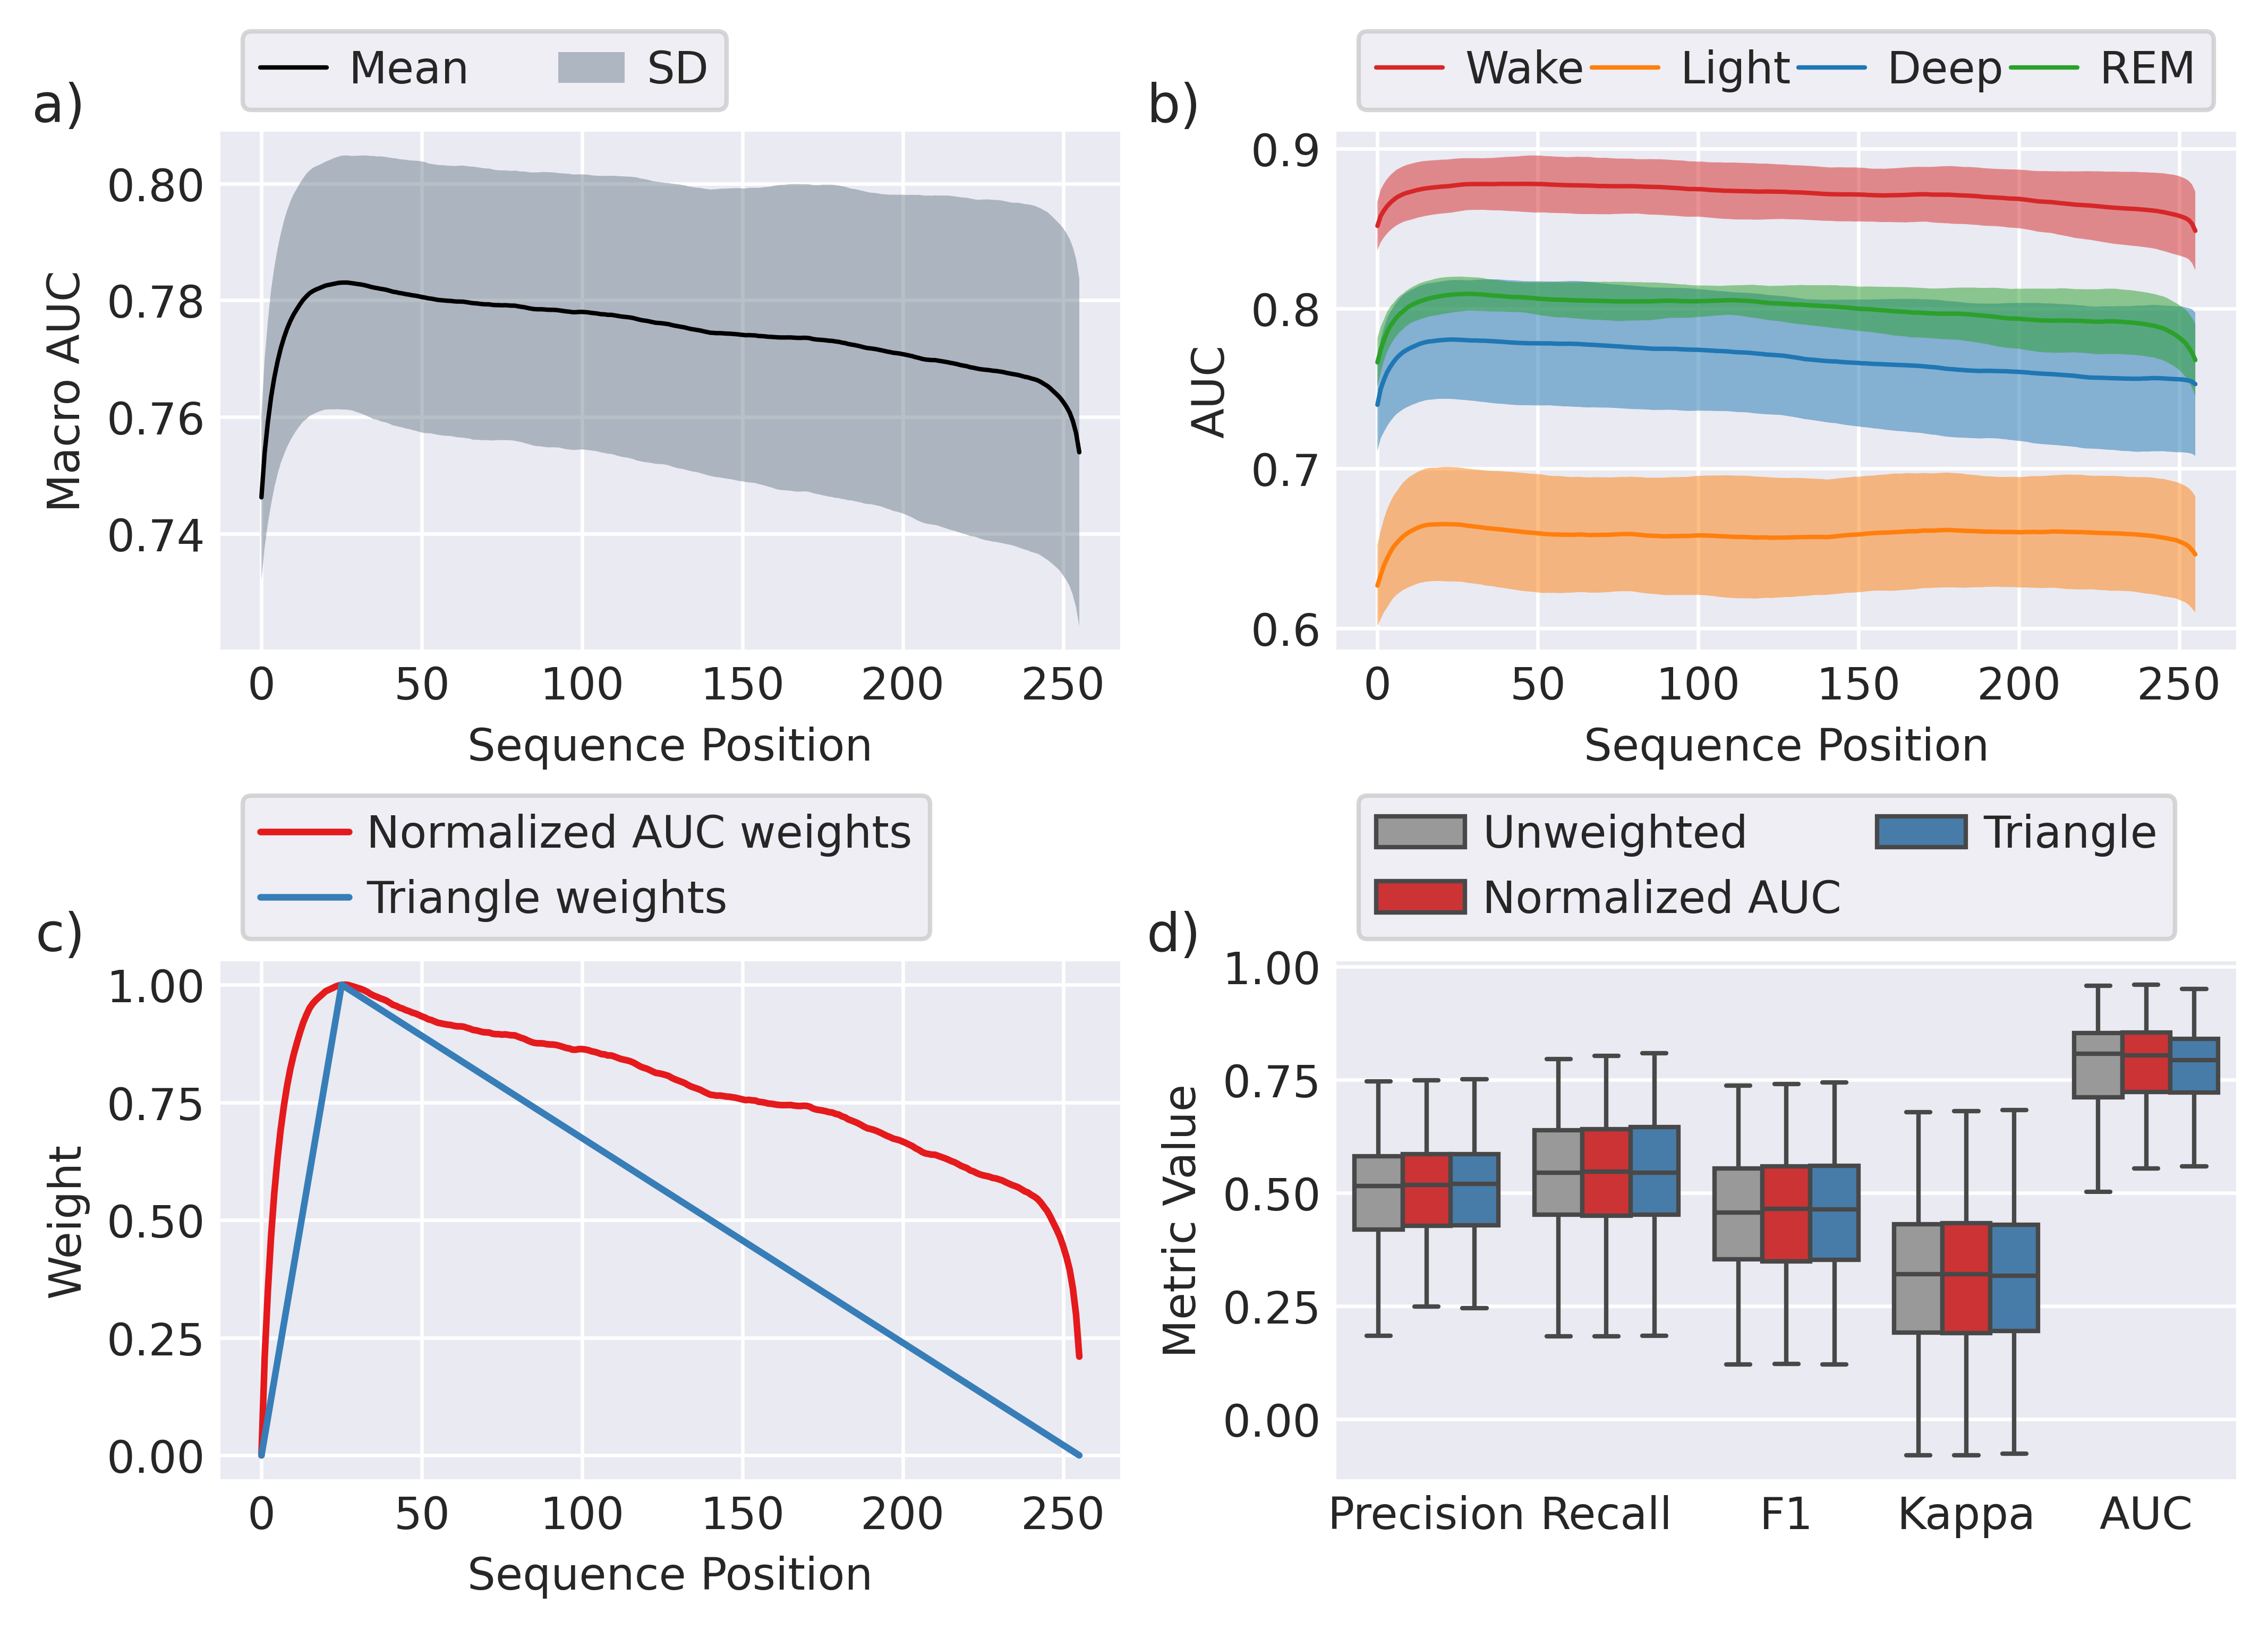

In [64]:
macro_results['weights'] = exp_i
macro_results['fold'] = fold_i
macro_results['subject'] = subject_i
melted = macro_results.melt(id_vars=['weights', 'fold', 'subject'])

norm_auc_weights = np.load('/oak/stanford/groups/mignot/projects/actigraphy_fm/results/norm_auc_weights.npy')
triangle_weights = np.load('/oak/stanford/groups/mignot/projects/actigraphy_fm/results/triangle_weights.npy')


fig, axes = plt.subplots(2,2,dpi=600,figsize=(7,5), layout = 'constrained')

for i, ax in enumerate(axes.ravel()):
    # Add alphabetic ordering
    ax.annotate(
        f'{chr(97+i)})',
        xy=(-0.18, 1.05), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize='large', verticalalignment='bottom', horizontalalignment='right',# fontfamily='verdana',
        bbox=dict(facecolor='none', edgecolor='none', pad=3.0)
    )
    ax.grid()

plot_macro_metric(axes[0,0], fold_auc_i)
axes[0,0].set_ylabel(f'Macro AUC')

plot_cw_metric(axes[0,1], fold_auc_i, order, labels, colors)
axes[0,1].set_ylabel('AUC')


for ax in axes[0]:
    ax.set_xlabel('Sequence Position')
    ax.set_xticks([0,50,100,150,200,250])
h, l = axes[0,0].get_legend_handles_labels()
h2, l2 = axes[0,1].get_legend_handles_labels()
# l.extend(l2)
# h.extend(h2)
axes[0,0].legend(handles=h, labels=l, bbox_to_anchor=(0, 1), loc='lower left', ncols=2, handlelength=1.5, handletextpad=0.5, frameon=True)
axes[0,1].legend(handles=h2, labels=l2, bbox_to_anchor=(0, 1, 1, 0), loc='lower left', ncols=4, mode='expand', handlelength=1.5, handletextpad=0.5, frameon=True)


axes[1,0].plot(norm_auc_weights, label='Normalized AUC weights', color = sns.color_palette(palette='Set1')[0])
axes[1,0].plot(triangle_weights, label='Triangle weights', color = sns.color_palette(palette='Set1')[1])
axes[1,0].set_ylabel('Weight')
axes[1,0].set_xlabel('Sequence Position')
axes[1,0].legend(title='', ncols=1, handletextpad = 0.4, columnspacing=0.8,  bbox_to_anchor=(0,1,1,1), loc='lower left', frameon=True)


ax = sns.boxplot(
    melted, x='variable', y='value', hue='weights', ax=axes[1,1], showfliers=False,
    palette=[sns.color_palette(palette='Set1')[i] for i in [-1,0,1]],
    hue_order = ['Unweighted', 'Normalized AUC', 'Triangle'],
)
ax.legend(title='', ncols=2, handletextpad = 0.4, columnspacing=0.8,  bbox_to_anchor=(0,1,1,1), loc='lower left', frameon=True)
ax.set_ylabel('Metric Value')
ax.set_xlabel('')





In [ ]:

fig, axes_2d = plt.subplots(len(metrics),2,figsize=(7,8),dpi = 600, layout = 'constrained', sharex=True)
if len(axes_2d.shape) == 1:
    axes_2d = axes_2d[None, :]
axes = axes_2d.ravel()

# plot_macro_metric(axes[0], fold_f1_i)
# axes[0].set_ylabel('Macro F1')
# axes[0].set_yticks([0.44, 0.47, 0.5, 0.53])
for i in range(len(metrics)):
    plot_macro_metric(axes_2d[i,0], metrics[i])
    axes_2d[i,0].set_ylabel(f'Macro {metric_labels[i]}')
    # axes[1].set_yticks([0.74, 0.77, 0.8])

    plot_cw_metric(axes_2d[i,1], metrics[i], order, labels, colors)
    axes_2d[i,1].set_ylabel(metric_labels[i])
# for i, metric in enumerate(metrics):
#     plot_cw_metric(axes[i+2], metric, order, labels, colors)
#     axes[i+2].set_ylabel(metric_labels[i])

for i, ax in enumerate(axes):
    # Add alphabetic ordering
    ax.annotate(
        f'{chr(97+i)})',
        xy=(-0.18, 1.0), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize='large', verticalalignment='bottom', horizontalalignment='right',# fontfamily='verdana',
        bbox=dict(facecolor='none', edgecolor='none', pad=3.0)
    )
    ax.grid()

for ax in axes_2d[-1]:
    ax.set_xlabel('Sequence Position')
    ax.set_xticks([0,50,100,150,200,250])
h, l = axes[0].get_legend_handles_labels()
h2, l2 = axes[1].get_legend_handles_labels()
# l.extend(l2)
# h.extend(h2)
axes[0].legend(handles=h, labels=l, bbox_to_anchor=(1, 1), loc='lower right', ncols=2, handlelength=1.5, handletextpad=0.5, frameon=True)
axes[1].legend(handles=h2, labels=l2, bbox_to_anchor=(0, 1, 1, 0), loc='lower left', ncols=4, mode='expand', handlelength=1.5, handletextpad=0.5, frameon=True)
# axes[3].legend(bbox_to_anchor=(1, 1), loc='upper left', ncols=2) #handlelength=1, frameon=True, framealpha=0.5
# fig.suptitle('Performance vs. Sequence Position') 
plt.show()